In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import pickle
import sys
import os
import yaml

from scipy.signal import welch

from eitprocessing.features.rate_detection import RateDetection
from eitprocessing.plotting.rate_detection import RateDetectionPlotting

sys.path.append(r"../src")
from preprocessing import butter_lowpass_filter

sys.path.append(r"../filter")
from MDN_bandstop import compute_welch_spectrum, normalize_to_peak, find_peak_properties_bandstop, remove_fundamental_and_harmonics
from EMD import emd 
# from Adaptive_NLMS_HR import nlms_hr_adaptive, hr_peaks, _smooth, 
# from Adaptive_NLMS_HR import run_nlms_hr_tracking
from Adaptive_NLMS_HR import process_pes_nlms, nlms_hour_analysis

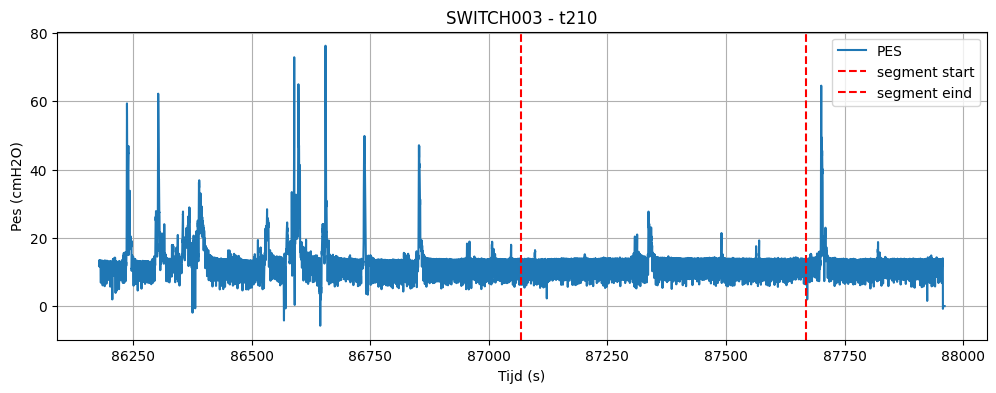

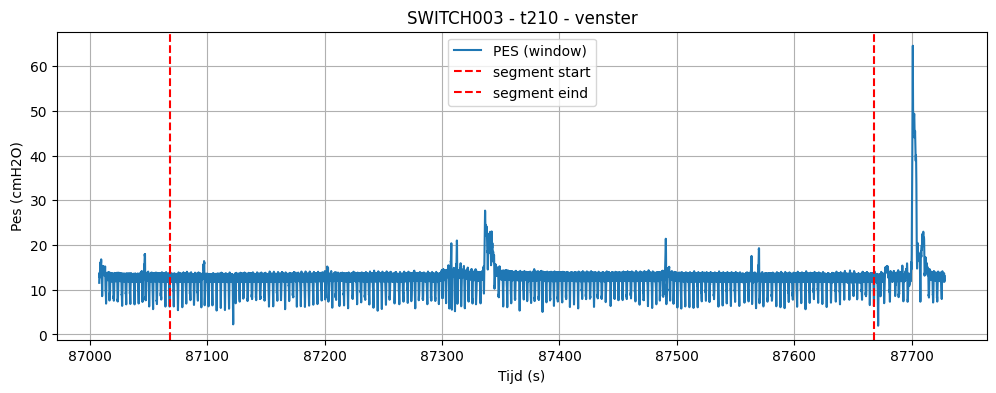

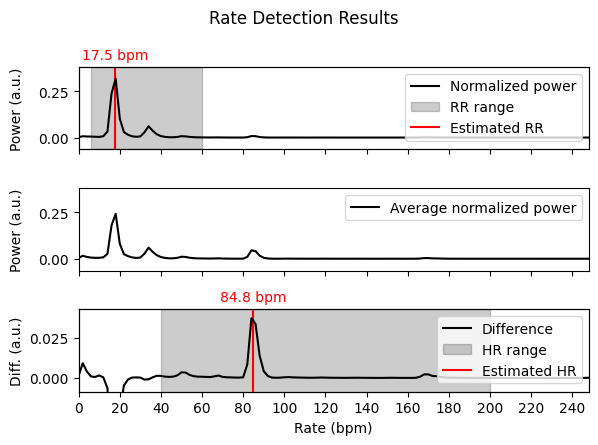

→ Patient: SWITCH003
→ Phase: t210
→ Tijdvenster stabiel segment: 87068s–87668s
→ Tijdvenster PES: 87008.0014688s-87727.997563s
→ Tijdvenster EIT: 87008.046s-87727.996s
→ RR (EIT): 17.5 bpm
→ HR (EIT): 84.8 bpm


In [14]:
# --------------------------------------------------
# Instellingen
# --------------------------------------------------
patient = "003" # 002, 003, 004, 005, 006, 009
phase = "t210" # preswitch, t0, t30, t60, t90, t120, t150, t180, t210
fs = 256

yaml_path = rf"\\storage\v\vcl17\ICCL\DATA\Onderzoek\SWITCH-SAFE\Data\Analysis data\interim\02_stable_segments\segment_timepoints\SWITCH{patient}_segments.yaml"
sync_path = rf"\\storage\v\vcl17\ICCL\DATA\Onderzoek\SWITCH-SAFE\Data\Analysis data\interim\01_synchronized_data\SWITCH{patient}_{phase}_sync"

# --------------------------------------------------
# YAML inladen en segment ophalen
# --------------------------------------------------
with open(yaml_path, "r") as f:
    segment_info = yaml.safe_load(f)

stable_segments = segment_info["stable_segment_timepoints"]

if phase not in stable_segments:
    raise ValueError(f"Fase '{phase}' niet gevonden in YAML voor patiënt {patient}.")

phase_info = stable_segments[phase]
start_times = phase_info["start_times"]
end_times = phase_info["end_times"]

if len(start_times) == 0 or len(end_times) == 0:
    raise ValueError(f"Geen segmenttijden gevonden voor patiënt {patient}, fase {phase}.")

if len(start_times) != len(end_times):
    raise ValueError(
        f"Ongelijk aantal start- en eindtijden voor patiënt {patient}, fase {phase}: "
        f"{len(start_times)} starts vs {len(end_times)} ends."
    )

# Voor nu nemen we het eerste segment
t_start = start_times[0]
t_end = end_times[0]

# --------------------------------------------------
# Gesynchroniseerde data inladen met PosixPath op windows
# --------------------------------------------------

class PosixPathFixUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == "pathlib" and name == "PosixPath":
            return pathlib.PurePosixPath
        return super().find_class(module, name)
with open(sync_path, "rb") as f:
    sequence = PosixPathFixUnpickler(f).load()

# PES ophalen
pes_signal = sequence.continuous_data["synchronized_pes"]
time = pes_signal.time
pes = pes_signal.values

# --------------------------------------------------
# Filteren
# --------------------------------------------------
pes_filt = butter_lowpass_filter(pes, cutoff=5, fs=fs)

# --------------------------------------------------
# Tijdvenster knippen (+/- 60 s marge)
# --------------------------------------------------
mask = (time >= t_start - 60) & (time <= t_end + 60)

time_window = time[mask]
pes_window = pes_filt[mask]

# --------------------------------------------------
# Plot volledig signaal met segmentmarkering
# --------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(time, pes_filt, label="PES")
plt.axvline(t_start, color="r", linestyle="--", label="segment start")
plt.axvline(t_end, color="r", linestyle="--", label="segment eind")
plt.xlabel("Tijd (s)")
plt.ylabel("Pes (cmH2O)")
plt.title(f"SWITCH{patient} - {phase}")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# Plot alleen venster rond segment
# --------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(time_window, pes_window, label="PES (window)")
plt.axvline(t_start, color="r", linestyle="--", label="segment start")
plt.axvline(t_end, color="r", linestyle="--", label="segment eind")
plt.xlabel("Tijd (s)")
plt.ylabel("Pes (cmH2O)")
plt.title(f"SWITCH{patient} - {phase} - venster")
plt.grid(True)
plt.legend()
plt.show()


# --------------------------------------------------
# EIT data: venster selecteren en HR/RR detectie
# --------------------------------------------------

# EIT-signaal ophalen
eit_signal = sequence.eit_data["raw"]
eit_time = eit_signal.time

# Tijdvenster bepalen (+/- 60 s marge rond stabiel segment)
eit_mask = (eit_time >= t_start - 60) & (eit_time <= t_end + 60)

idx = np.where(eit_mask)[0]
start_idx = idx[0]
end_idx = idx[-1] + 1

eit_window = eit_signal[start_idx:end_idx]

# --------------------------------------------------
# HR en RR detectie op EIT data en visualisatie
# --------------------------------------------------

rd = RateDetection(subject_type="adult")
captures = {}

rr_eit, hr_eit = rd.apply(eit_window, captures=captures)

plotter = RateDetectionPlotting(rd)
fig = plotter.plot(**captures)

plt.show()

print(f"→ Patient: SWITCH{patient}")
print(f"→ Phase: {phase}")
print(f"→ Tijdvenster stabiel segment: {t_start}s–{t_end}s")
print(f"→ Tijdvenster PES: {time_window[0]}s-{time_window[-1]}s")
print(f"→ Tijdvenster EIT: {eit_time[start_idx]}s-{eit_time[end_idx-1]}s")
print(f"→ RR (EIT): {rr_eit * 60:.1f} bpm")
print(f"→ HR (EIT): {hr_eit * 60:.1f} bpm")

## Fundamental frequency detection using MDN bandstop

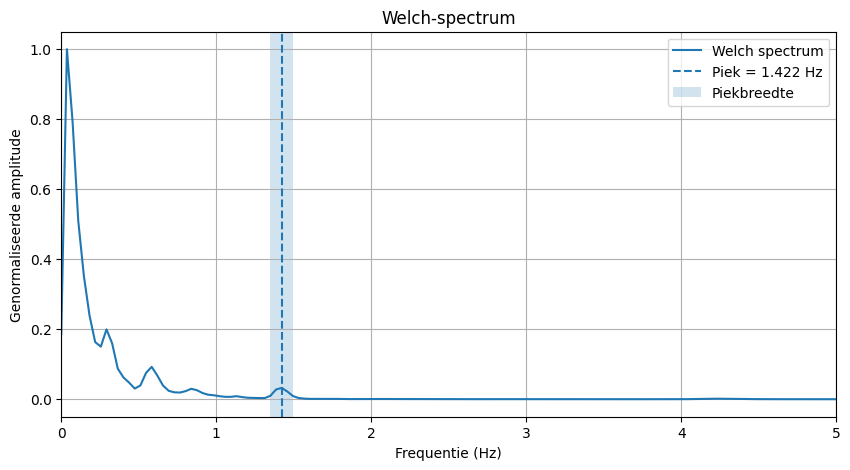

85.30902876673314


In [ ]:
def estimate_fundamental_frequency_welch(pes, fs=256, fmin=0.67, fmax=4.0):
    pes = np.asarray(pes, dtype=float)
    pes = pes - np.mean(pes)

    freq, mag = compute_welch_spectrum(pes, fs=fs)
    mag = normalize_to_peak(mag)

    fundamental_freq, fundamental_amp, peak_width, left_freq, right_freq = find_peak_properties_bandstop(
        freq, mag,
        f_min=fmin,
        f_max=fmax,
        percent_of_peak=0.5
    )

    plt.figure(figsize=(10, 5))
    plt.plot(freq, mag, label="Welch spectrum")
    plt.axvline(fundamental_freq, linestyle="--", label=f"Piek = {fundamental_freq:.3f} Hz")
    plt.axvspan(left_freq, right_freq, alpha=0.2, label="Piekbreedte")
    plt.xlim(0.67, 4)
    plt.xlabel("Frequentie (Hz)")
    plt.ylabel("Genormaliseerde amplitude")
    plt.title("Welch-spectrum")
    plt.grid(True)
    plt.legend()
    plt.show()

    return fundamental_freq

fund_freq = estimate_fundamental_frequency_welch(pes, fs=256)
print(fund_freq*60)

## HR detection with sliding window

In [ ]:
# ------------------------------
# 1. Analyse van één venster
# ------------------------------

(
    pes_used,
    cgo,
    res,
    cgo_s,
    peaks,
    peak_t,
    t_hr,
    hr,
    f_peak,
    f_grid,
    mse,
    f_nlms,
    sharp,
    w_state
) = process_pes_nlms(
    time_window=time_window,
    pes_window=pes_window,
    fs=fs,
    f0=fund_freq,
    M=1,
    A=10,
    L=80,
    mu=0.001,
    bpm=(40, 180),
    prominence=0.35,
    smooth_sec=0.12,
    edge_sec=1.0,
    scan_span_bpm=20,
    scan_grid=41
)

In [ ]:
# ----------------------------
# Plot
# ----------------------------
t_start = time_window[0]
t_end = time_window[-1]

fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=False)
fig.suptitle("NLMS-CGO-analyse en hartslagschatting", fontsize=14)


# -----------------------------------------------
# Helper for dynamic y-limits
# -----------------------------------------------
def dynamic_ylim(signal, margin=0.1):
    signal = np.asarray(signal)

    if len(signal) == 0:
        return -1, 1

    y_min = np.min(signal)
    y_max = np.max(signal)
    y_range = y_max - y_min

    if y_range == 0:
        y_range = max(abs(y_min), 1.0)

    return y_min - margin * y_range, y_max + margin * y_range


# ---------------------------
# 1. Original PES signal
# ---------------------------
axes[0].plot(time_window, pes_window, label="Origineel PES", alpha=0.7)
axes[0].set_title("Origineel PES-signaal")
axes[0].set_ylabel("Amplitude")
axes[0].set_xlim(t_start, t_end)
axes[0].set_ylim(*dynamic_ylim(pes_window))
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)


# ---------------------------
# 2. CGO
# ---------------------------
axes[1].plot(time_window, cgo, label="CGO", alpha=0.8)
axes[1].plot(time_window, cgo_s, label="Smoothed CGO", linewidth=2)
axes[1].set_title("CGO-signaal")
axes[1].set_ylabel("Amplitude")
axes[1].set_xlim(t_start, t_end)
axes[1].set_ylim(*dynamic_ylim(cgo_s))
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)


# ------------------------
# 3. Residual
# ------------------------
axes[2].plot(time_window, res, label="Residual", alpha=0.8)
axes[2].set_title("Residusignaal")
axes[2].set_ylabel("Amplitude")
axes[2].set_xlim(t_start, t_end)
axes[2].set_ylim(*dynamic_ylim(res))
axes[2].legend(loc="upper right")
axes[2].grid(True, alpha=0.3)


# ------------------------
# 4. CGO + peaks
# ------------------------
axes[3].plot(time_window, cgo_s, label="Smoothed CGO", linewidth=2)

if len(peaks) > 0:
    axes[3].plot(
        time_window[peaks],
        cgo_s[peaks],
        "o",
        label="Gedetecteerde pieken",
        markersize=5
    )

    for p_i in peaks:
        axes[3].axvline(time_window[p_i], linestyle="--", alpha=0.2)

axes[3].set_title("CGO met piekdetectie")
axes[3].set_ylabel("Amplitude")
axes[3].set_xlim(t_start, t_end)
axes[3].set_ylim(*dynamic_ylim(cgo_s))
axes[3].legend(loc="upper right")
axes[3].grid(True, alpha=0.3)


# -------------
# 5. Heart rate
# -------------
if len(hr) > 0:
    axes[4].plot(t_hr, hr, label="Hartslag uit CGO-pieken", linewidth=2)

axes[4].set_title("Hartslag over venster")
axes[4].set_ylabel("BPM")
axes[4].set_xlabel("Tijd [s]")
axes[4].set_xlim(t_start, t_end)

if len(hr) > 0:
    axes[4].set_ylim(*dynamic_ylim(hr))

axes[4].legend(loc="upper right")
axes[4].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(60 * f_grid, mse, label="MSE over frequentie")
if f_nlms is not None:
    plt.axvline(60 * f_nlms, linestyle="--", label=f"Beste f = {60*f_nlms:.1f} bpm")
plt.title("NLMS frequency preference")
plt.xlabel("BPM")
plt.ylabel("MSE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
if len(hr) > 0:
    print(f"Gemiddelde hartslag uit pieken: {np.mean(hr):.1f} bpm")
    print(f"Mediaan hartslag uit pieken:    {np.median(hr):.1f} bpm")
else:
    print("⚠️ Geen geldige HR bepaald uit piekdetectie.")

if f_peak is not None:
    print(f"Mediane piekfrequentie:         {60*f_peak:.1f} bpm")

if f_nlms is not None:
    print(f"Beste NLMS-frequentie:          {60*f_nlms:.1f} bpm")

if sharp is not None:
    print(f"NLMS sharpness/confidence:      {sharp:.3f}")

## Analyse geheel

In [ ]:
results = nlms_hour_analysis(
    pes=pes,
    time=time,
    fs=fs,
    f0_init_func=lambda pes, time, fs: fund_freq,
    win_sec=60,
    step_sec=30,
    max_minutes=120,
    bpm=(40, 180),
    M=1,
    A=10,
    L=80,
    mu=0.001,
    prominence=0.35,
    smooth_sec=0.12,
    edge_sec=1.0,
    scan_span_bpm=20,
    scan_grid=41
)

In [ ]:
t = [r["time"] / 60 for r in results]
f0 = [60 * r["f0"] for r in results]
f_peak = [60 * r["f_peak"] if r["f_peak"] is not None else np.nan for r in results]
f_nlms = [60 * r["f_nlms"] if r["f_nlms"] is not None else np.nan for r in results]
sharp = [r["sharp"] for r in results]

plt.figure(figsize=(14, 6))
plt.plot(t, f0, "-o", label="Fixed f0")
plt.plot(t, f_peak, "-o", label="Peak")
plt.plot(t, f_nlms, "-o", label="NLMS")
plt.xlabel("Time [min]")
plt.ylabel("BPM")
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Overzicht van HR-schattingen")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(t, sharp, "-o")
plt.title("NLMS confidence")
plt.xlabel("Time [min]")
plt.ylabel("Sharpness")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
idx = 10
d = results[idx]

plt.figure(figsize=(14, 12))

# 1) Original PES
plt.subplot(5, 1, 1)
plt.plot(d["t"], d["x"], label="PES")
plt.legend()
plt.title("PES")

# 2) CGO
plt.subplot(5, 1, 2)
plt.plot(d["t"], d["cgo"], label="CGO")
plt.plot(d["t"], d["cgo_s"], label="Smoothed", alpha=0.8)
plt.legend()
plt.title("CGO")

# 3) Residual
plt.subplot(5, 1, 3)
plt.plot(d["t"], d["res"])
plt.title("Residual")

# 4) Peaks
plt.subplot(5, 1, 4)
plt.plot(d["t"], d["cgo_s"])
plt.plot(d["t"][d["peaks"]], d["cgo_s"][d["peaks"]], "ro")
plt.title("Peaks")

# 5) NLMS frequency preference
plt.subplot(5, 1, 5)
plt.plot(60 * d["f_grid"], d["mse"])
if d["f_nlms"] is not None:
    plt.axvline(60 * d["f_nlms"], linestyle="--")
plt.title("NLMS frequency preference")

plt.tight_layout()
plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.signal import find_peaks, savgol_filter


# # ---------------- NLMS ----------------
# def _nlms_window(x, t, f0, M=1, A=10, L=30, mu=0.002, w_init=None):
#     ref = np.zeros_like(x, dtype=float)
#     for h in range(1, M + 1):
#         ref += A * np.sin(2 * np.pi * h * f0 * t)

#     if w_init is None:
#         w = np.zeros(L, dtype=float)
#     else:
#         w = np.asarray(w_init, dtype=float).copy()

#     y = np.zeros(len(x), dtype=float)
#     e = np.zeros(len(x), dtype=float)

#     for k in range(L, len(x)):
#         xv = ref[k - L:k][::-1]
#         y[k] = np.dot(w, xv)
#         e[k] = x[k] - y[k]
#         w += mu * e[k] * xv / (np.dot(xv, xv) + 1e-6)

#     return y, e, w


# # ---------------- SMOOTH ----------------
# def _smooth(x, fs, smooth_sec=0.08, poly=2):
#     win = max(5, int(smooth_sec * fs))
#     if win % 2 == 0:
#         win += 1
#     if win >= len(x):
#         return x.copy()
#     poly = min(poly, win - 1)
#     return savgol_filter(x, window_length=win, polyorder=poly)


# # ---------------- STABLE PART ----------------
# def _stable_slice(n, fs, edge_sec=1.0, L=30):
#     edge = max(int(edge_sec * fs), L)

#     if 2 * edge >= n:
#         return slice(0, n)

#     return slice(edge, n - edge)


# # ---------------- PEAK DETECTION ----------------
# def hr_peaks(cgo, time, fs, f0=None, bpm=(40, 180), prominence=0.35,
#              smooth_sec=0.08, edge_sec=1.0, L=30):
#     stable = _stable_slice(len(cgo), fs, edge_sec=edge_sec, L=L)

#     cgo_mid = cgo[stable]
#     time_mid = time[stable]

#     cgo_s_mid = _smooth(cgo_mid, fs, smooth_sec=smooth_sec)

#     min_bpm, max_bpm = bpm
#     min_dist = max(1, int(fs * 60 / max_bpm))
#     prom = prominence * np.std(cgo_s_mid)

#     peaks_mid, _ = find_peaks(cgo_s_mid, distance=min_dist, prominence=prom)
#     peak_t = time_mid[peaks_mid]

#     # peaks terugzetten naar indices van volledig window
#     peak_offset = stable.start if stable.start is not None else 0
#     peaks = peaks_mid + peak_offset

#     cgo_s = cgo.copy()
#     cgo_s[stable] = cgo_s_mid

#     if len(peak_t) < 2:
#         return cgo_s, peaks, peak_t, None

#     ibi = np.diff(peak_t)
#     ibi = ibi[ibi > 0]

#     if len(ibi) == 0:
#         return cgo_s, peaks, peak_t, None

#     hr = 60 / ibi
#     ok = (hr >= min_bpm) & (hr <= max_bpm)

#     if not np.any(ok):
#         return cgo_s, peaks, peak_t, None

#     f_med = np.median(hr[ok]) / 60.0
#     return cgo_s, peaks, peak_t, f_med


# # ---------------- NLMS SCAN ----------------
# def _scan_f0(x, t, f0_center, span_bpm=40, n_grid=41, M=1, A=10, L=30, mu=0.002):
#     if f0_center is None:
#         return None, None, None, None

#     span_hz = span_bpm / 60.0
#     f_grid = np.linspace(f0_center - span_hz / 2, f0_center + span_hz / 2, n_grid)

#     mse = []

#     for f in f_grid:
#         _, e, _ = _nlms_window(x, t, f, M=M, A=A, L=L, mu=mu, w_init=None)
#         mse.append(np.mean(e[L:] ** 2))

#     mse = np.array(mse)
#     best_f = f_grid[np.argmin(mse)]
#     sharpness = np.std(mse) / (np.mean(mse) + 1e-8)

#     return f_grid, mse, best_f, sharpness


# # ---------------- MAIN ANALYSIS ----------------
# def nlms_hour_analysis(
#     pes,
#     time,
#     fs,
#     f0_init_func,
#     win_sec=10,
#     step_sec=60,
#     max_minutes=60,
#     bpm=(40, 180),
#     M=1,
#     A=10,
#     L=30,
#     mu=0.002,
#     prominence=0.35,
#     smooth_sec=0.08,
#     edge_sec=1.0,
#     scan_span_bpm=20,
#     scan_grid=41
# ):
#     n_win = int(win_sec * fs)
#     n_step = int(step_sec * fs)

#     f0 = f0_init_func(pes[:n_win], time[:n_win], fs)

#     results = []
#     w_state = None

#     for i, start in enumerate(range(0, len(pes) - n_win, n_step)):
#         current_time = i * step_sec

#         if current_time > max_minutes * 60:
#             break

#         stop = start + n_win
#         x = pes[start:stop]
#         t = time[start:stop]

#         # NLMS met stateful w
#         cgo, res, w_state = _nlms_window(
#             x, t, f0, M=M, A=A, L=L, mu=mu, w_init=w_state
#         )

#         # Peaks op stabiel middenstuk, mediane HR
#         cgo_s, peaks, peak_t, f_peak = hr_peaks(
#             cgo, t, fs,
#             f0=f0,
#             bpm=bpm,
#             prominence=prominence,
#             smooth_sec=smooth_sec,
#             edge_sec=edge_sec,
#             L=L
#         )

#         # Scan rond gefixeerde f0
#         f_grid, mse, f_nlms, sharp = _scan_f0(
#             x, t, f0,
#             span_bpm=scan_span_bpm,
#             n_grid=scan_grid,
#             M=M, A=A, L=L, mu=mu
#         )

#         results.append({
#             "time": current_time,
#             "f0": f0,               # gefixeerd
#             "f_peak": f_peak,
#             "f_nlms": f_nlms,
#             "sharp": sharp,
#             "x": x,
#             "res": res,
#             "cgo": cgo,
#             "cgo_s": cgo_s,
#             "t": t,
#             "peaks": peaks,
#             "peak_t": peak_t,
#             "mse": mse,
#             "f_grid": f_grid,
#             "w": w_state.copy() if w_state is not None else None
#         })

#         # GEEN update van f0 -> gefixeerd
#         print(
#             f"[t={current_time/60:.1f} min] "
#             f"f0={60*f0:.1f} | "
#             f"peak={None if f_peak is None else round(60*f_peak,1)} | "
#             f"nlms={None if f_nlms is None else round(60*f_nlms,1)} | "
#             f"sharp={None if sharp is None else round(sharp,3)}"
#         )

#     return results

# results = nlms_hour_analysis(
#     pes=pes,
#     time=time,
#     fs=fs,
#     f0_init_func=lambda pes, time, fs: fund_freq,
#     win_sec=60,
#     step_sec=30,
#     max_minutes=120,
#     bpm=(40, 180),
#     M=1,
#     A=10,
#     L=80,
#     mu=0.001,
#     prominence=0.35,
#     smooth_sec=0.12,
#     edge_sec=1.0
# )

# t = [r["time"]/60 for r in results]
# f0 = [60*r["f0"] for r in results]
# f_peak = [60*r["f_peak"] if r["f_peak"] is not None else np.nan for r in results]
# f_nlms = [60*r["f_nlms"] if r["f_nlms"] is not None else np.nan for r in results]
# sharp = [r["sharp"] for r in results]

# plt.figure(figsize=(14,6))
# plt.plot(t, f0, "-o", label="Tracked f0")
# plt.plot(t, f_peak, "-o", label="Peak")
# plt.plot(t, f_nlms, "-o", label="NLMS")
# plt.xlabel("Time [min]")
# plt.ylabel("BPM")
# plt.legend()
# plt.grid()
# plt.title("1-hour overview (1-min resolution)")
# plt.show()

# plt.figure(figsize=(14,4))
# plt.plot(t, sharp, "-o")
# plt.title("NLMS confidence")
# plt.xlabel("Time [min]")
# plt.grid()
# plt.show()

# idx = 10
# d = results[idx]

# plt.figure(figsize=(14,12))

# # 1) Original PES
# plt.subplot(5,1,1)
# plt.plot(d["t"], d["x"], label="PES")
# plt.legend()
# plt.title("PES")

# # 2) CGO
# plt.subplot(5,1,2)
# plt.plot(d["t"], d["cgo"], label="CGO")
# plt.plot(d["t"], d["cgo_s"], label="Smoothed", alpha=0.8)
# plt.legend()
# plt.title("CGO")

# # 3) Residual
# plt.subplot(5,1,3)
# plt.plot(d["t"], d["res"])
# plt.title("Residual")

# # 4) Peaks
# plt.subplot(5,1,4)
# plt.plot(d["t"], d["cgo_s"])
# plt.plot(d["t"][d["peaks"]], d["cgo_s"][d["peaks"]], "ro")
# plt.title("Peaks")

# # 5) NLMS frequency preference
# plt.subplot(5,1,5)
# plt.plot(60*d["f_grid"], d["mse"])
# if d["f_nlms"] is not None:
#     plt.axvline(60*d["f_nlms"], linestyle="--")
# plt.title("NLMS frequency preference")

# plt.tight_layout()
# plt.show()



NameError: name 'x' is not defined